# Load Trajectory

In [ ]:
from evo.core.trajectory import PosePath3D, PoseTrajectory3D
from scipy.spatial.transform import Rotation as Rot
import numpy as np
import dill
import mathUtils as math
import utils as utils
import matplotlib.pyplot as plt

dataset = "10"
folder = "../notebooks/Dataset_Syntetic/Sets"

dumpfile = open(f"{folder}/{dataset}/gt.dill", "rb")
trajectory: PoseTrajectory3D = dill.load(dumpfile)
dumpfile.close()

# grep poses and timestamps
poses = trajectory.poses_se3
timestamps = trajectory.timestamps

# Calculate Drift

In [60]:

# Translation offset
t_trans = np.array([0, 0, 0])

# Rotation Offset
w_rot = np.array([0.0,  0.0,  0.0]) # rotation around z

T_sys = math.compute_systematic_error_transform(w_rot,t_trans)

#print(T_sys)

# Define noise covariance matrix (Q) for stochastic noise
Q_trans = np.array([0.00001, 0.00001, 0.00005])  # Noise for [x, y, z]
Q_rot   = np.array([0.0000001, 0.0000001, 0.0000001])  #noise on rotaion vector
#Q_trans = np.array([0.0, 0.0, 0.0])  # Noise for [x, y, z]
#Q_rot   = np.array([0.0, 0.0, 0.0])  # noise on rotaion vector
Sigma = np.diag(np.concatenate((Q_trans, Q_rot)))

print(Sigma)

[[1.e-05 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00]
 [0.e+00 1.e-05 0.e+00 0.e+00 0.e+00 0.e+00]
 [0.e+00 0.e+00 5.e-05 0.e+00 0.e+00 0.e+00]
 [0.e+00 0.e+00 0.e+00 1.e-07 0.e+00 0.e+00]
 [0.e+00 0.e+00 0.e+00 0.e+00 1.e-07 0.e+00]
 [0.e+00 0.e+00 0.e+00 0.e+00 0.e+00 1.e-07]]


In [61]:
print((Rot.from_rotvec(np.array(w_rot))).as_euler('zyx', degrees=True))

[0. 0. 0.]


In [62]:
# Loop through all poses to add systematic and stochastic errors
poses_with_drift = [poses[0]]

for i in range(0, len(poses)-1):

    # Extract current and previous poses
    p_t = poses[i]
    p_tp1 = poses[i + 1]

    # Compute relative motion in the global frame
    T_t = np.linalg.inv(p_t @ T_sys) @ (p_tp1 @ T_sys)

    T_t_noise = math.compute_noise_transform(Sigma)


    poses_with_drift.append(poses_with_drift[-1] @ T_t  @ T_t_noise)

# Convert back to PoseTrajectory3D
trajectory_with_drift = PoseTrajectory3D(
    timestamps=timestamps,
    poses_se3=poses_with_drift
)


# Visualization

<Axes: title={'center': '2D Trajectory Visualization'}, xlabel='X (m)', ylabel='Y (m)'>

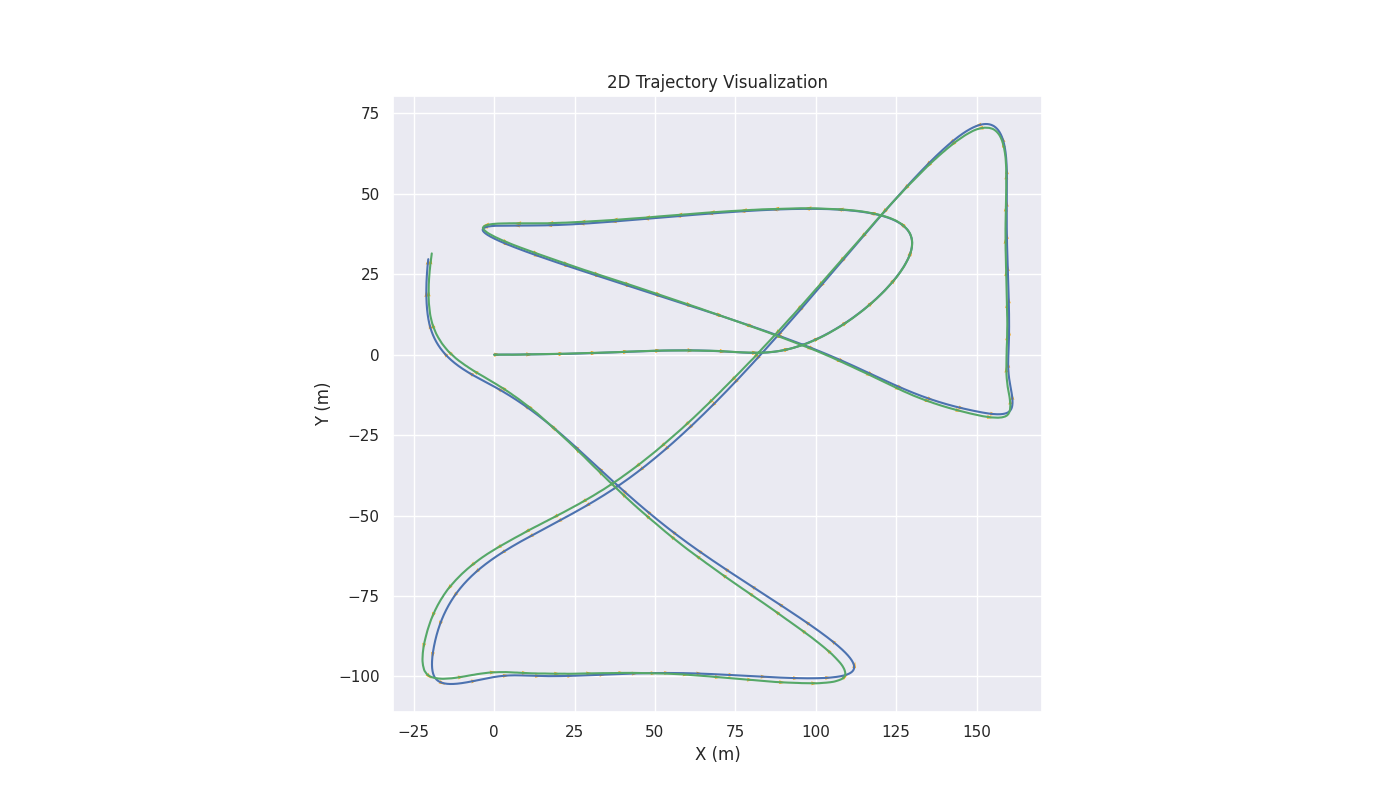

In [63]:
%matplotlib inline
%matplotlib widget 

plt.close('all')

mode_3D = False
fig = plt.figure(figsize=(14, 8))
grid = fig.add_gridspec(1,1)
ax_trajectory = fig.add_subplot(grid[0, 0], projection='3d' if mode_3D else None)

utils.plot_trajectory(fig, ax_trajectory, trajectory, mode_3D, 10.0, True)
utils.plot_trajectory(fig, ax_trajectory, trajectory_with_drift, mode_3D, 10.0, True)

In [64]:
%matplotlib inline
%matplotlib widget 
import sys
import os
sys.path.append('..')
import notebooks.shared as sh


print(trajectory)
print(trajectory_with_drift)

sh.traj_ref = trajectory
sh.traj_est = trajectory_with_drift

sh.count = 0
sh.results = []
_ = sh.ipywidgets.interact_manual(sh.callback_ape, pose_relation=sh.pose_relation_selector, plot_mode=sh.plotmode_selector,
                               **{c.description: c.value for c in sh.check_boxes_ape})

20120 poses, 1127.160m path length, 2012.088s duration
20120 poses, 1139.661m path length, 2012.088s duration


interactive(children=(Dropdown(description='pose_relation', index=1, options={'full transformation': <PoseRela…

In [ ]:


trajectory_with_drift.meta["Name"] = "odom"
trajectory_with_drift.meta["topic"] = "/localization/odometry/odom_lidar"
trajectory_with_drift.meta["frame_id"] = "odom"
trajectory_with_drift.meta["child_frame_id"] = "base_link"
trajectory_with_drift.meta["publish_transform"] = True
trajectory_with_drift.meta["publish_orientation"] = False
trajectory_with_drift.meta["frequency"] = 10

# Save the new trajectory
output_file = f"{folder}/{dataset}/odom.dill"
with open(output_file, "wb") as f:
    dill.dump(trajectory_with_drift, f)

print(f"Drifted trajectory with linear and angular drift (per-axis) saved to {output_file}")


Drifted trajectory with linear and angular drift (per-axis) saved to ../notebooks/Dataset_Syntetic/Sets/10/odom.dill
